# Klasifikasi Kategori Profit — Global Skincare & Beauty E-Store

Notebook ini bertujuan membangun model **klasifikasi** untuk memprediksi kategori profit (`Rugi`, `Untung Rendah`, `Untung Tinggi`) dari setiap transaksi pada dataset e-commerce skincare & beauty global, menggunakan beberapa algoritma machine learning yang dibandingkan performanya.

## 1. Import Library & Load Data

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

url = 'https://docs.google.com/spreadsheets/d/e/2PACX-1vQHKCQ5-LS4nL7Ger0OE2kxachW17ueOdGL0EwbDsNzctoxBWZdDCtnlCerAV7rFA/pub?output=csv'
df = pd.read_csv(url)

df.head()

,Row ID,Order ID,Order Date,Customer ID,Segment,City,State,Country,Country latitude,Country longitude,Region,Market,Subcategory,Category,Product,Quantity,Sales,Discount,Profit
0,46682,IZ-2012-LW699061-40911,1/3/2020,LW-699061,Corporate,Mosul,Ninawa,Iraq,33.223191,43.679291,Western Asia,Asia Pacific,"bath oils, bubbles and soaks",Body care,Head & Shoulders Classic Clean Shampoo,20,600,0,300
1,10124,US-2012-BT1130518-40912,1/4/2020,BT-1130518,Self-Employed,Pilar,Alagoas,Brazil,-14.235004,-51.925280,South America,LATAM,"bath oils, bubbles and soaks",Body care,Kiehl's Ultra Facial Overnight Hydrating Masque,2,40,"0,6",-4
2,9067,MX-2012-AW1093031-40912,1/4/2020,AW-1093031,Self-Employed,Santiago de Cuba,Santiago de Cuba,Cuba,21.521757,-77.781167,Caribbean,LATAM,"bath oils, bubbles and soaks",Body care,Golden Vine Bracelet,1,151,0,"75,5"
3,130,MX-2012-BT1130531-40912,1/4/2020,BT-1130531,Self-Employed,Manzanillo,Granma,Cuba,21.521757,-77.781167,Caribbean,LATAM,"bath oils, bubbles and soaks",Body care,Kiehl's Crème de Corps Smoothing Oil-to-Foam B...,4,40,0,20
4,24072,IN-2012-KM1666027-40914,1/6/2020,KM-1666027,Consumer,Huadian,Jilin,China,35.861660,104.195397,Eastern Asia,Asia Pacific,"bath oils, bubbles and soaks",Body care,NARS Single Eyeshadow Sophia Cool Brown,1,11,0,"5,5"


Mengimpor library yang diperlukan (pandas, numpy, matplotlib, seaborn) dan memuat dataset dari Google Sheets. Fungsi df.head() digunakan untuk menampilkan 5 baris pertama data guna memastikan proses pemuatan data berhasil.

## 2. Data Understanding

In [26]:
print("Jumlah Baris dan Kolom:")
print(df.shape)

print("\nInformasi Dataset:")
print(df.info())

print("\nTipe Data:")
print(df.dtypes)

Jumlah Baris dan Kolom:
(51290, 19)

Informasi Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 19 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Row ID             51290 non-null  int64  
 1   Order ID           51290 non-null  object 
 2   Order Date         51290 non-null  object 
 3   Customer ID        51290 non-null  object 
 4   Segment            51290 non-null  object 
 5   City               51290 non-null  object 
 6   State              51290 non-null  object 
 7   Country            51290 non-null  object 
 8   Country latitude   51290 non-null  float64
 9   Country longitude  51290 non-null  float64
 10  Region             51290 non-null  object 
 11  Market             51290 non-null  object 
 12  Subcategory        51290 non-null  object 
 13  Category           51290 non-null  object 
 14  Product            51290 non-null  object 
 15  Quantity      

Memeriksa struktur dataset meliputi dimensi data (df.shape), informasi tipe data serta keberadaan missing values (df.info()), dan memastikan tipe data setiap kolom (df.dtypes) sudah sesuai untuk proses analisis.

## 3. Data Cleaning

Kolom `Discount` dan `Profit` masih bertipe object karena memakai koma sebagai pemisah desimal, perlu dikonversi ke numerik. Selain itu dicek missing value dan duplikasi data.

In [27]:
df['Discount'] = df['Discount'].astype(str).str.replace(',', '.')
df['Profit'] = df['Profit'].astype(str).str.replace(',', '.')

df['Discount'] = pd.to_numeric(df['Discount'], errors='coerce')
df['Profit'] = pd.to_numeric(df['Profit'], errors='coerce')

df.dtypes

,0
Row ID,int64
Order ID,object
Order Date,object
Customer ID,object
Segment,object
City,object
State,object
Country,object
Country latitude,float64
Country longitude,float64


In [28]:
print("Jumlah missing value per kolom:")
print(df.isnull().sum())

Jumlah missing value per kolom:
Row ID               0
Order ID             0
Order Date           0
Customer ID          0
Segment              0
City                 0
State                0
Country              0
Country latitude     0
Country longitude    0
Region               0
Market               0
Subcategory          0
Category             0
Product              0
Quantity             0
Sales                0
Discount             0
Profit               0
dtype: int64


In [29]:
print("Jumlah baris duplikat:", df.duplicated().sum())

df = df.drop_duplicates().reset_index(drop=True)
print("Jumlah baris setelah pengecekan duplikat:", df.shape[0])

Jumlah baris duplikat: 0
Jumlah baris setelah pengecekan duplikat: 51290


In [30]:
df.describe()

,Row ID,Country latitude,Country longitude,Quantity,Sales,Discount,Profit
count,51290.00000,51290.000000,51290.000000,51290.000000,51290.000000,51290.000000,51290.000000
mean,25645.50000,24.506298,-4.585665,5.415832,127.074946,0.142908,20.772346
std,14806.29199,24.119393,80.298692,4.908234,236.074764,0.212280,83.582680
min,1.00000,-40.900557,-106.346771,1.000000,2.000000,0.000000,-1746.000000
25%,12823.25000,12.879721,-95.712891,2.000000,25.000000,0.000000,0.000000
50%,25645.50000,35.861660,2.213749,4.000000,56.000000,0.000000,7.200000
75%,38467.75000,38.963745,43.679291,7.000000,132.000000,0.200000,25.000000
max,51290.00000,61.924110,174.885971,20.000000,3940.000000,0.850000,1820.000000


Menggunakan df.describe() untuk mendapatkan ringkasan statistik (rata-rata, nilai min/max, deviasi standar) dari kolom numerik sebagai gambaran umum sebaran data dan Melakukan verifikasi kualitas data dengan mengecek nilai kosong (isnull().sum()) dan menghapus data duplikat (drop_duplicates()) untuk memastikan akurasi hasil analisis.


## 4. Exploratory Data Analysis (EDA)

### 4.1 Distribusi Variabel Numerik

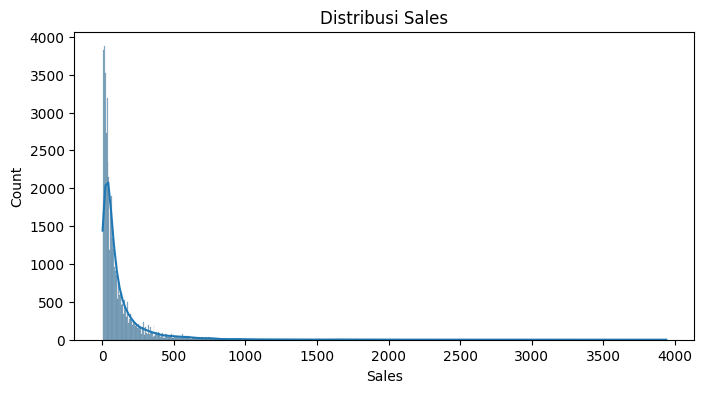

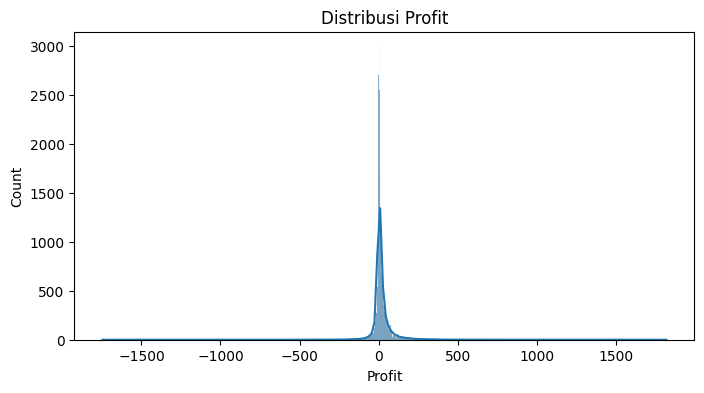

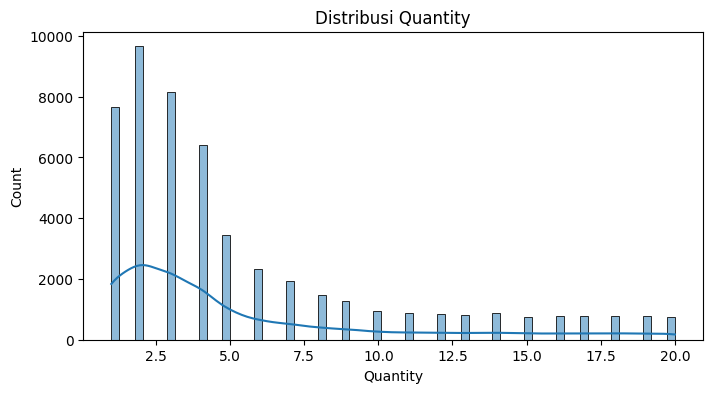

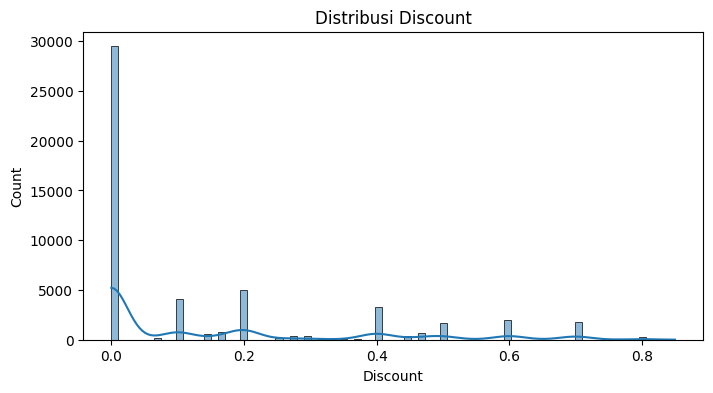

In [31]:
numerical_cols = ['Sales', 'Profit', 'Quantity', 'Discount']

for col in numerical_cols:
    plt.figure(figsize=(8,4))
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribusi {col}')
    plt.show()

Membuat histogram untuk variabel Sales, Profit, Quantity, dan Discount guna melihat pola atau sebaran data secara visual.

### 4.2 Deteksi Outlier

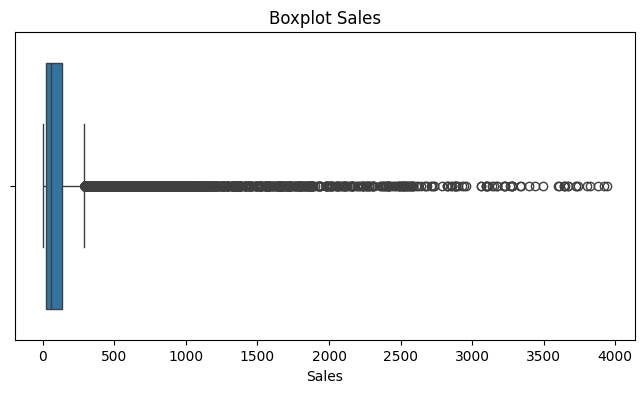

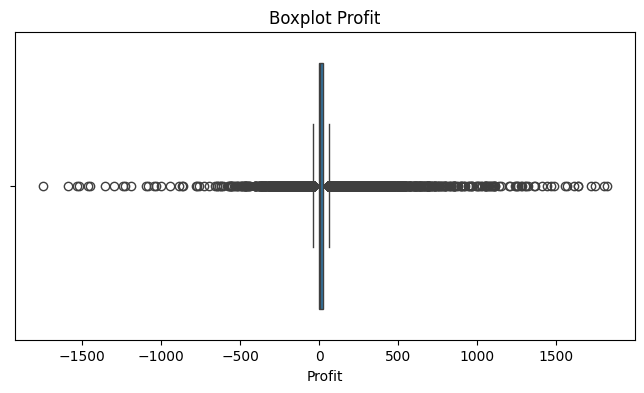

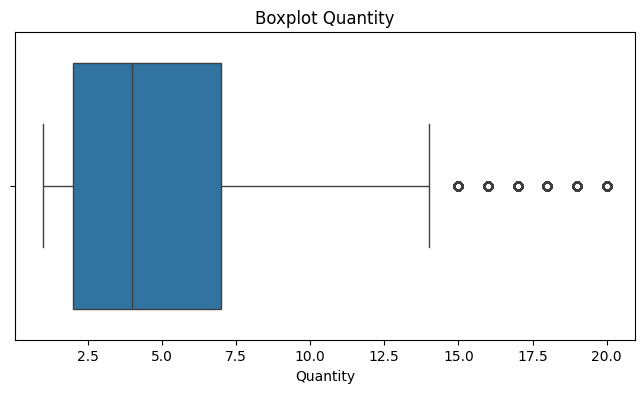

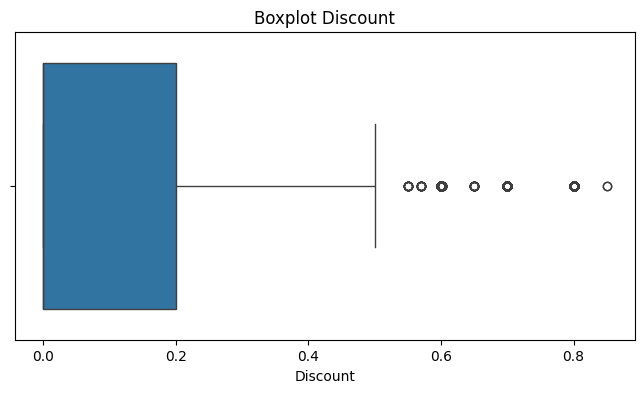

In [32]:
for col in numerical_cols:
    plt.figure(figsize=(8,4))
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot {col}')
    plt.show()

Menggunakan boxplot untuk mendeteksi adanya data ekstrem (outlier) yang bisa memengaruhi performa model machine learning di tahap selanjutnya.

### 4.3 Distribusi Variabel Kategorikal

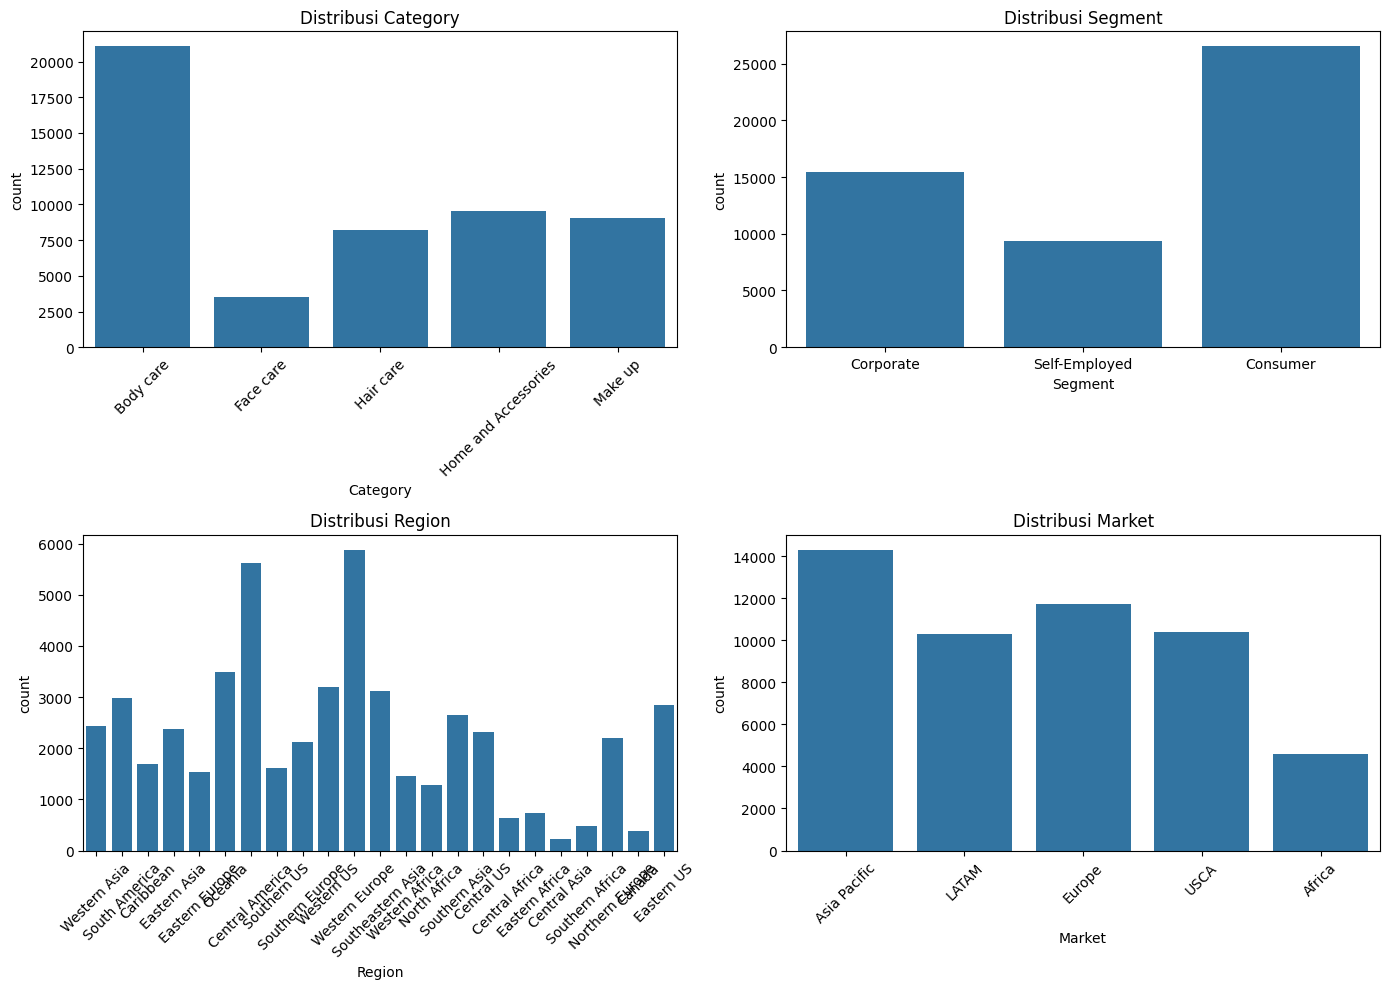

In [33]:
fig, axes = plt.subplots(2, 2, figsize=(14,10))

sns.countplot(data=df, x='Category', ax=axes[0,0])
axes[0,0].set_title('Distribusi Category')
axes[0,0].tick_params(axis='x', rotation=45)

sns.countplot(data=df, x='Segment', ax=axes[0,1])
axes[0,1].set_title('Distribusi Segment')

sns.countplot(data=df, x='Region', ax=axes[1,0])
axes[1,0].set_title('Distribusi Region')
axes[1,0].tick_params(axis='x', rotation=45)

sns.countplot(data=df, x='Market', ax=axes[1,1])
axes[1,1].set_title('Distribusi Market')
axes[1,1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

Memvisualisasikan jumlah data berdasarkan kategori (Category, Segment, Region, Market) menggunakan count plot untuk memahami proporsi tiap kelompok data.

### 4.4 Hubungan Variabel Numerik dengan Profit

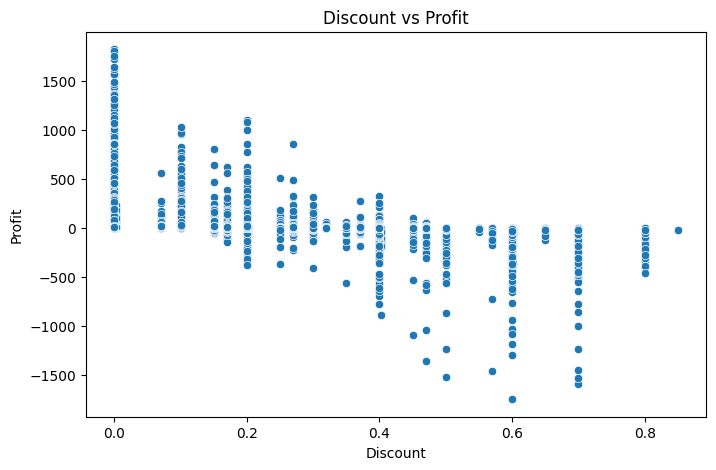

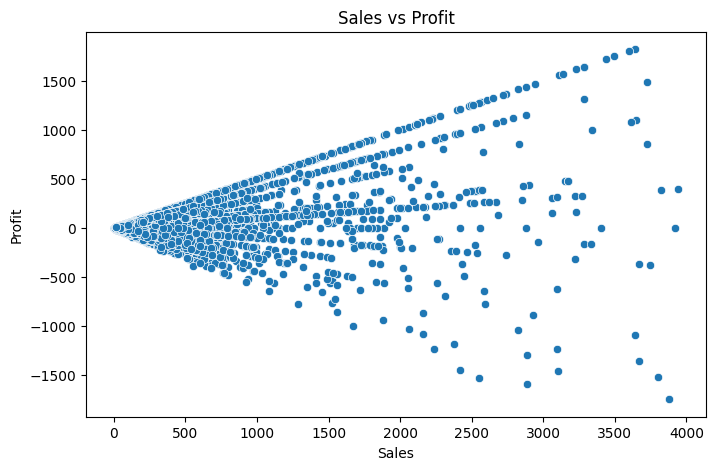

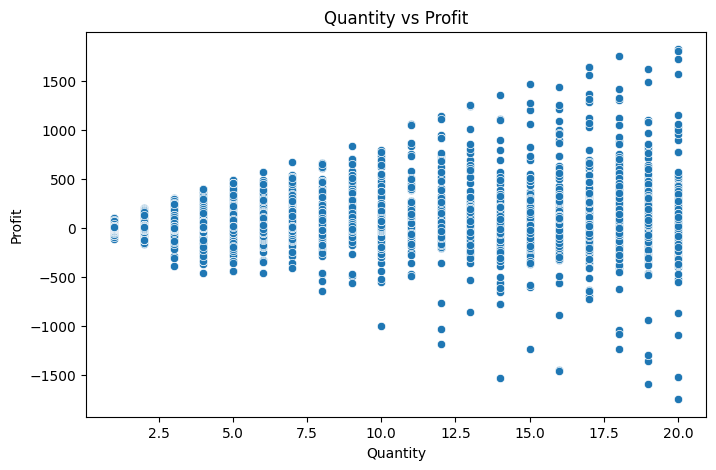

In [34]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x='Discount', y='Profit')
plt.title('Discount vs Profit')
plt.show()

plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x='Sales', y='Profit')
plt.title('Sales vs Profit')
plt.show()

plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x='Quantity', y='Profit')
plt.title('Quantity vs Profit')
plt.show()

Membuat scatterplot untuk melihat tren hubungan antara Discount, Sales, dan Quantity terhadap Profit, guna memvalidasi korelasi antar variabel tersebut.

### 4.5 Profit Berdasarkan Segmen, Region, dan Market

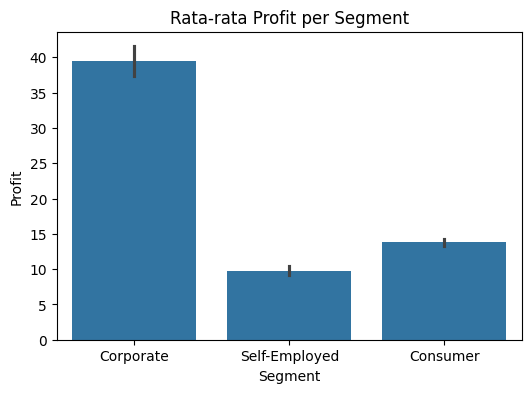

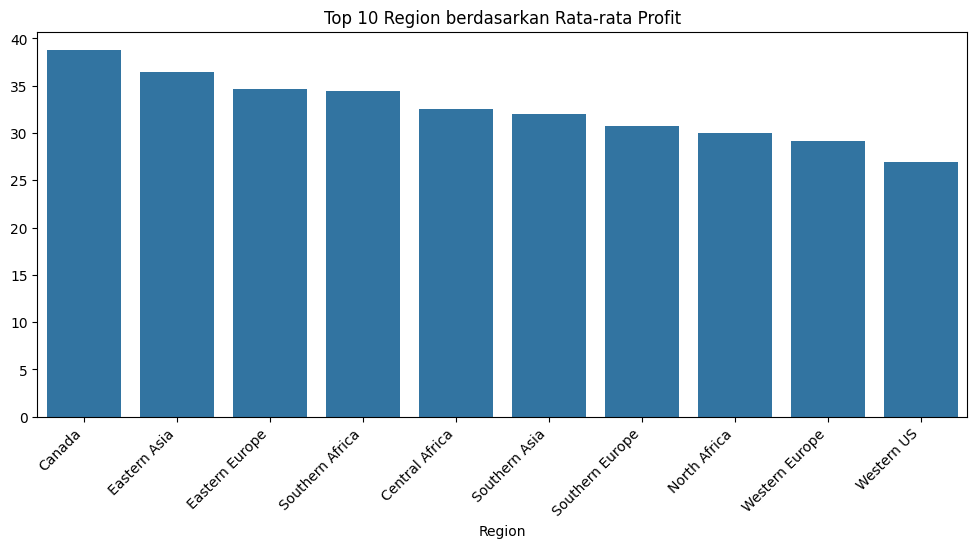

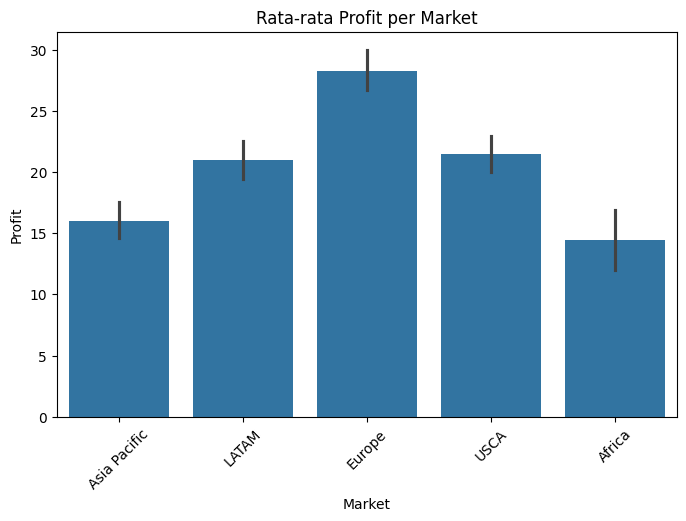

In [35]:
plt.figure(figsize=(6,4))
sns.barplot(data=df, x='Segment', y='Profit')
plt.title('Rata-rata Profit per Segment')
plt.show()

top_region = df.groupby('Region')['Profit'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(12,5))
sns.barplot(x=top_region.index, y=top_region.values)
plt.xticks(rotation=45, ha='right')
plt.title('Top 10 Region berdasarkan Rata-rata Profit')
plt.show()

plt.figure(figsize=(8,5))
sns.barplot(data=df, x='Market', y='Profit')
plt.xticks(rotation=45)
plt.title('Rata-rata Profit per Market')
plt.show()

Membandingkan rata-rata profit berdasarkan segmen, wilayah, dan pasar untuk mengidentifikasi area bisnis yang paling menguntungkan.

### 4.6 Produk dengan Sales Tertinggi

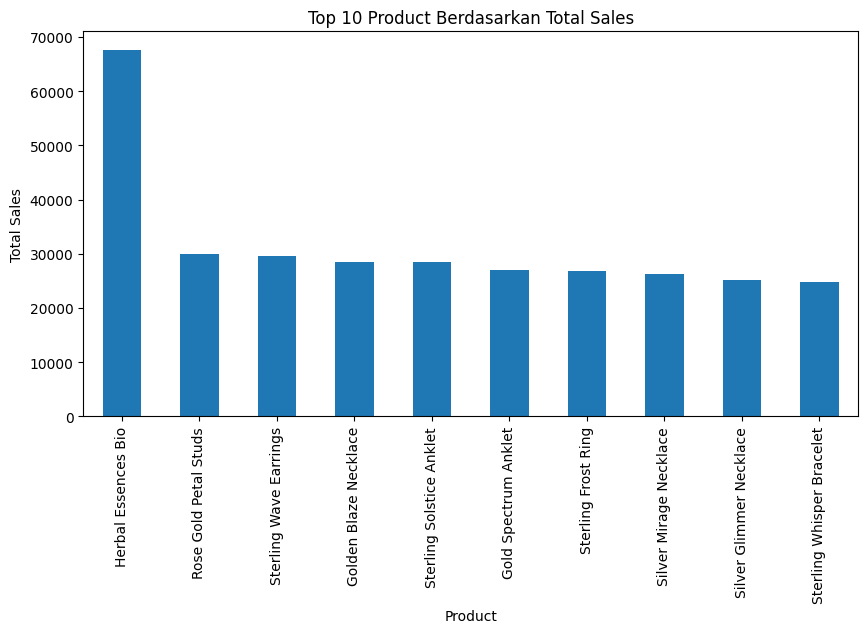

In [36]:
top_product_sales = df.groupby('Product')['Sales'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
top_product_sales.plot(kind='bar')
plt.title('Top 10 Product Berdasarkan Total Sales')
plt.ylabel('Total Sales')
plt.show()

Mengelompokkan data berdasarkan produk untuk mencari 10 produk dengan total penjualan tertinggi (Top Sales).

Product
Herbal Essences Bio                                      1041
Neutrogena Hydro Boost Gel Cream                          699
Head & Shoulders Classic Clean Conditioner                324
Redken Color Extend Magnetics Conditioner                 319
L'Oréal Infallible 24HR Eyeshadow Bronzed Taupe           303
Pantene Pro-V Daily Moisture Renewal Conditioner          273
NYX Hot Singles Eyeshadow Chandelier Warm Peach           272
TRESemmé Moisture Rich Conditioner                        266
Urban Decay Eyeshadow Solstice Red with Green Shift       260
Maybelline Color Tattoo 24HR Eyeshadow Tough as Taupe     260
Name: Quantity, dtype: int64


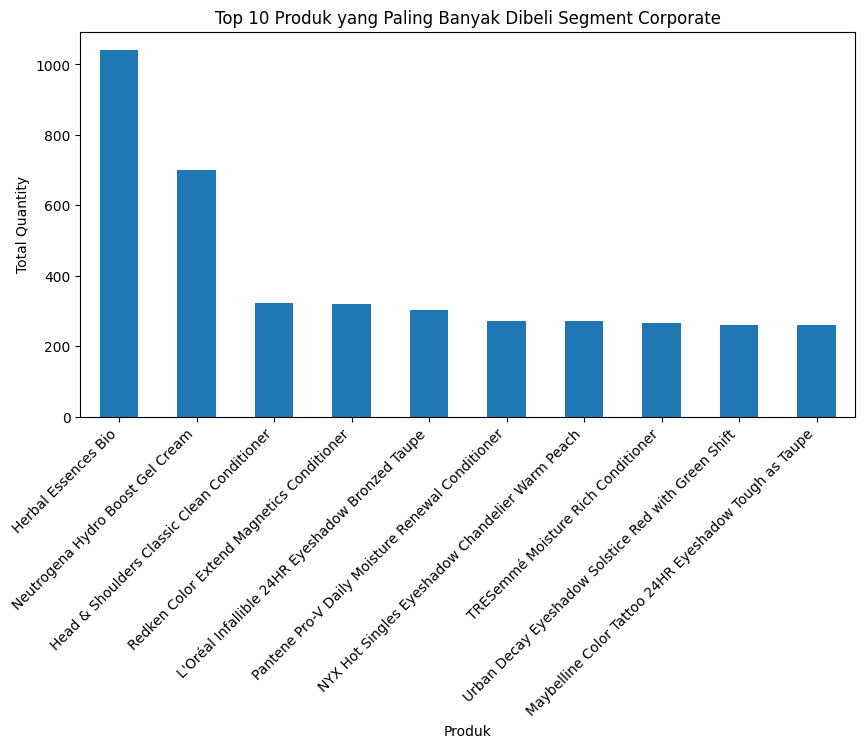

In [37]:
corporate_df = df[df['Segment'] == 'Corporate']

top_products = (
    corporate_df.groupby('Product')['Quantity']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print(top_products)

plt.figure(figsize=(10,5))
top_products.plot(kind='bar')
plt.title('Top 10 Produk yang Paling Banyak Dibeli Segment Corporate')
plt.xlabel('Produk')
plt.ylabel('Total Quantity')
plt.xticks(rotation=45, ha='right')
plt.show()

Disini terlihat jumlah baranag yang dibeli corporate

### 4.7 Discount Rata-rata per Category

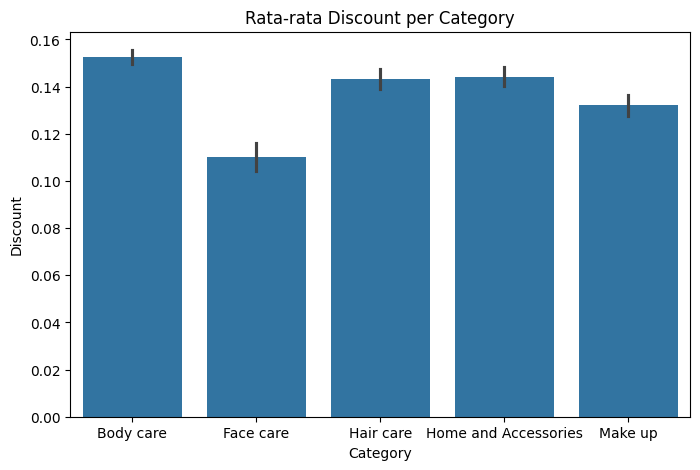

In [38]:
plt.figure(figsize=(8,5))
sns.barplot(data=df, x='Category', y='Discount')
plt.title('Rata-rata Discount per Category')
plt.show()

Memvisualisasikan rata-rata diskon per kategori produk untuk melihat kebijakan potongan harga yang diterapkan perusahaan.

## 5. Analisis Korelasi Variabel Numerik

In [39]:
numeric_df = df.select_dtypes(include='number').drop(columns=['Row ID', 'Country latitude', 'Country longitude'])

corr_profit = numeric_df.corr()['Profit'].sort_values(ascending=False)
print(corr_profit)

Profit      1.000000
Sales       0.417419
Quantity    0.214679
Discount   -0.316544
Name: Profit, dtype: float64


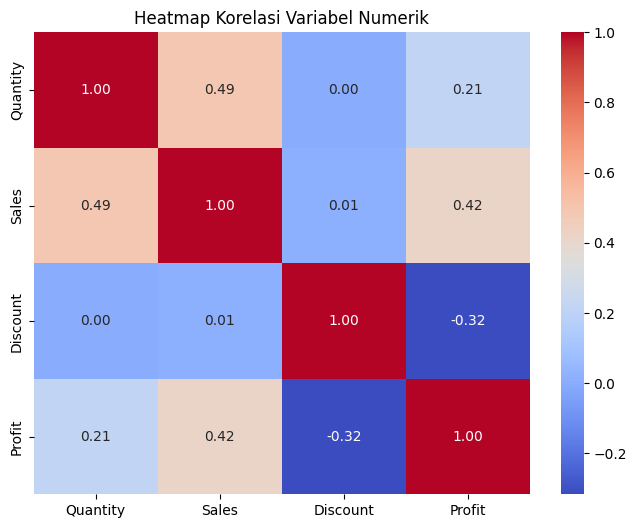

In [40]:
plt.figure(figsize=(8,6))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Heatmap Korelasi Variabel Numerik')
plt.show()

Menggunakan heatmap untuk menampilkan matriks korelasi antar variabel numerik, membantu mengidentifikasi fitur mana yang paling berpengaruh terhadap Profit.

## 6. Membuat Target Klasifikasi (`Profit_Category`)

Target dibuat dari nilai `Profit` per transaksi, dibagi menjadi 3 kelas berdasarkan median:
- **Rugi**: Profit ≤ 0
- **Untung Rendah**: 0 < Profit ≤ median
- **Untung Tinggi**: Profit > median

In [41]:
median_profit = df['Profit'].median()
print("Median Profit:", median_profit)

def label_profit(profit):
    if profit <= 0:
        return "Rugi"
    elif profit <= median_profit:
        return "Untung Rendah"
    else:
        return "Untung Tinggi"

df['Profit_Category'] = df['Profit'].apply(label_profit)

count = df['Profit_Category'].value_counts()
percent = (df['Profit_Category'].value_counts(normalize=True) * 100).round(2)

distribution = pd.DataFrame({
    'Jumlah': count,
    'Persentase (%)': percent
})

print(distribution)

Median Profit: 7.2
                 Jumlah  Persentase (%)
Profit_Category                        
Untung Tinggi     25455           49.63
Rugi              12985           25.32
Untung Rendah     12850           25.05


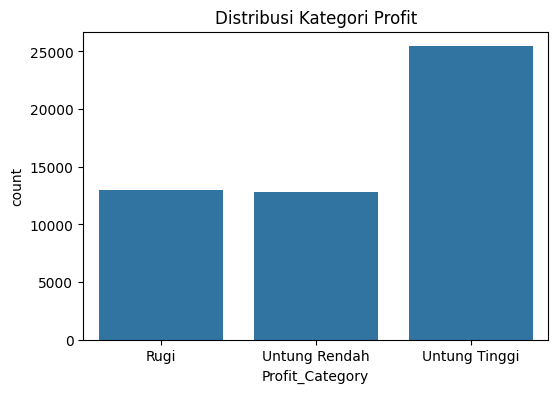

In [42]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='Profit_Category', order=['Rugi', 'Untung Rendah', 'Untung Tinggi'])
plt.title('Distribusi Kategori Profit')
plt.show()

Mengubah kolom Profit menjadi label kategori (Rugi, Untung Rendah, Untung Tinggi) berdasarkan nilai median untuk kebutuhan supervised learning.

## 7. Data Preprocessing untuk Modeling

Beberapa kolom seperti `City`, `State`, `Country`, dan `Product` memiliki **cardinality sangat tinggi** (ribuan nilai unik). Jika kolom-kolom ini di-*one-hot encode* secara langsung, jumlah fitur akan meledak menjadi ribuan kolom dan membuat training model (terutama SVM) menjadi sangat lambat. Oleh karena itu kolom-kolom tersebut di-drop, sementara `Order Date` diubah menjadi fitur tahun/bulan/hari yang lebih ringkas.

In [43]:
from sklearn.preprocessing import LabelEncoder

df['Order Date'] = pd.to_datetime(df['Order Date'], errors='coerce')
df['Order_Year'] = df['Order Date'].dt.year
df['Order_Month'] = df['Order Date'].dt.month
df['Order_DayOfWeek'] = df['Order Date'].dt.dayofweek

drop_cols = [
    'Row ID', 'Order ID', 'Customer ID', 'Order Date',
    'City', 'State', 'Country', 'Product',
    'Country latitude', 'Country longitude',
    'Profit', 'Profit_Category'
]

X = df.drop(columns=drop_cols)
y = df['Profit_Category']

le = LabelEncoder()
y = le.fit_transform(y)
print("Mapping kelas target:", dict(zip(le.classes_, le.transform(le.classes_))))

categorical_cols = ['Segment', 'Region', 'Market', 'Subcategory', 'Category']
X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

print("\nJumlah fitur setelah encoding:", X.shape[1])
X.head()

Mapping kelas target: {'Rugi': np.int64(0), 'Untung Rendah': np.int64(1), 'Untung Tinggi': np.int64(2)}

Jumlah fitur setelah encoding: 54


,Quantity,Sales,Discount,Order_Year,Order_Month,Order_DayOfWeek,Segment_Corporate,Segment_Self-Employed,Region_Caribbean,Region_Central Africa,...,Subcategory_foundations and concealers,Subcategory_fragrances,Subcategory_hair colors and toners,Subcategory_hand creams,Subcategory_shampoos and conditioners,Subcategory_vitamins and supplements,Category_Face care,Category_Hair care,Category_Home and Accessories,Category_Make up
0,20,600,0.0,2020,1,4,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,2,40,0.6,2020,1,5,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False
2,1,151,0.0,2020,1,5,False,True,True,False,...,False,False,False,False,False,False,False,False,False,False
3,4,40,0.0,2020,1,5,False,True,True,False,...,False,False,False,False,False,False,False,False,False,False
4,1,11,0.0,2020,1,0,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


Menyiapkan data: mengekstraksi tanggal, menghapus kolom yang tidak relevan/ber-kardinalitas tinggi, melakukan Label Encoding untuk target, dan One-Hot Encoding untuk fitur kategorikal.

## 8. Train-Test Split & Feature Scaling

In [44]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Shape X_train:", X_train.shape)
print("Shape X_test:", X_test.shape)

Shape X_train: (41032, 54)
Shape X_test: (10258, 54)


Membagi dataset menjadi data train (80%) dan test (20%), lalu melakukan standarisasi fitur agar model dapat bekerja dengan bobot yang seimbang.

## 9. Training & Evaluasi Model

Empat algoritma klasifikasi dibandingkan: Logistic Regression, Decision Tree, Random Forest, dan SVM. Akurasi pada data train *dan* test dicatat sekaligus untuk melihat indikasi overfitting.

In [45]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

def evaluate_model(model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)
    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)

    train_acc = accuracy_score(y_train, y_pred_train)
    test_acc = accuracy_score(y_test, y_pred_test)
    precision = precision_score(y_test, y_pred_test, average='weighted')
    recall = recall_score(y_test, y_pred_test, average='weighted')
    f1 = f1_score(y_test, y_pred_test, average='weighted')

    return model, y_pred_test, train_acc, test_acc, precision, recall, f1

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'SVM': SVC(kernel='rbf', random_state=42)
}

results = []
trained_models = {}
predictions = {}

for name, model in models.items():
    fitted_model, y_pred, train_acc, test_acc, prec, rec, f1 = evaluate_model(
        model, X_train, X_test, y_train, y_test
    )
    trained_models[name] = fitted_model
    predictions[name] = y_pred
    results.append([name, train_acc, test_acc, prec, rec, f1])

results_df = pd.DataFrame(
    results,
    columns=['Model', 'Train Accuracy', 'Test Accuracy', 'Precision', 'Recall', 'F1-Score']
)
results_df = results_df.sort_values(by='Test Accuracy', ascending=False)
print(results_df)

                 Model  Train Accuracy  Test Accuracy  Precision    Recall  \
1        Decision Tree        1.000000       0.999318   0.999318  0.999318   
2        Random Forest        1.000000       0.994736   0.994748  0.994736   
0  Logistic Regression        0.953938       0.951453   0.951225  0.951453   
3                  SVM        0.923231       0.913043   0.912295  0.913043   

   F1-Score  
1  0.999317  
2  0.994727  
0  0.951212  
3  0.911196  


Melatih empat model (LogReg, Decision Tree, Random Forest, SVM) dan menghitung metrik performa (Accuracy, Precision, Recall, F1-Score).

## 10. Confusion Matrix & Classification Report per Model


=== Logistic Regression ===
               precision    recall  f1-score   support

         Rugi       0.98      0.98      0.98      2597
Untung Rendah       0.92      0.89      0.91      2570
Untung Tinggi       0.95      0.97      0.96      5091

     accuracy                           0.95     10258
    macro avg       0.95      0.95      0.95     10258
 weighted avg       0.95      0.95      0.95     10258



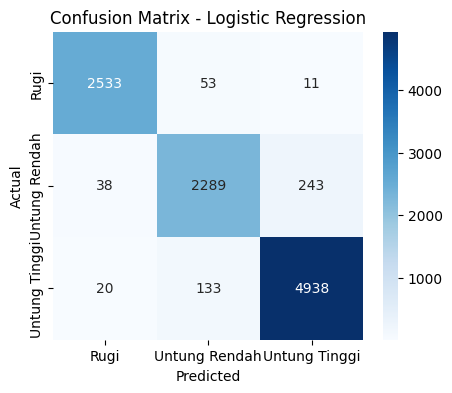


=== Decision Tree ===
               precision    recall  f1-score   support

         Rugi       1.00      1.00      1.00      2597
Untung Rendah       1.00      1.00      1.00      2570
Untung Tinggi       1.00      1.00      1.00      5091

     accuracy                           1.00     10258
    macro avg       1.00      1.00      1.00     10258
 weighted avg       1.00      1.00      1.00     10258



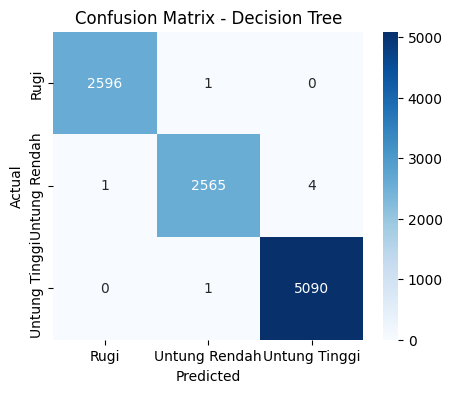


=== Random Forest ===
               precision    recall  f1-score   support

         Rugi       1.00      1.00      1.00      2597
Untung Rendah       1.00      0.98      0.99      2570
Untung Tinggi       0.99      1.00      1.00      5091

     accuracy                           0.99     10258
    macro avg       1.00      0.99      0.99     10258
 weighted avg       0.99      0.99      0.99     10258



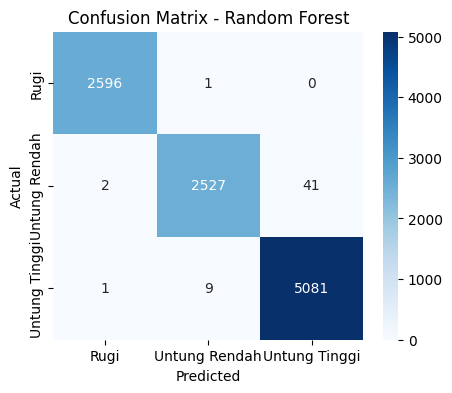


=== SVM ===
               precision    recall  f1-score   support

         Rugi       0.98      1.00      0.99      2597
Untung Rendah       0.88      0.76      0.82      2570
Untung Tinggi       0.89      0.95      0.92      5091

     accuracy                           0.91     10258
    macro avg       0.92      0.90      0.91     10258
 weighted avg       0.91      0.91      0.91     10258



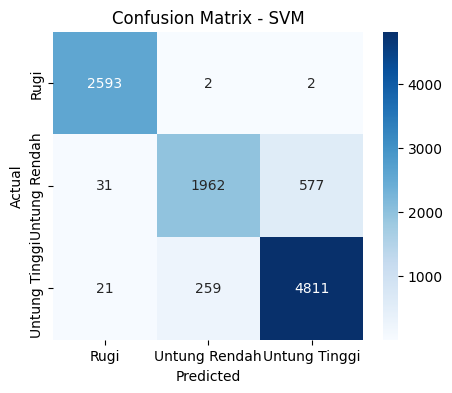

In [46]:
from sklearn.metrics import confusion_matrix, classification_report

for name, y_pred in predictions.items():
    print(f"\n=== {name} ===")
    print(classification_report(y_test, y_pred, target_names=le.classes_))

    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=le.classes_, yticklabels=le.classes_)
    plt.title(f'Confusion Matrix - {name}')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.show()

Menampilkan Confusion Matrix per model untuk memetakan di mana kesalahan prediksi terjadi antara kategori Rugi dan Untung.

## 11. Cek Overfitting (Train vs Test Accuracy)

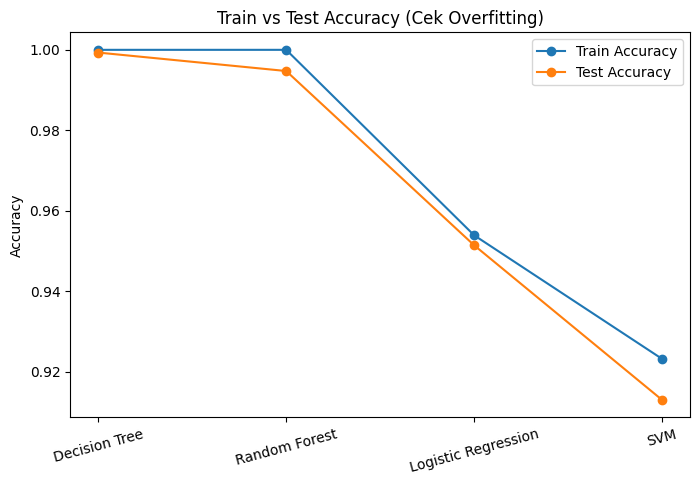

                 Model  Train Accuracy  Test Accuracy  Gap (Train-Test)
1        Decision Tree        1.000000       0.999318          0.000682
2        Random Forest        1.000000       0.994736          0.005264
0  Logistic Regression        0.953938       0.951453          0.002486
3                  SVM        0.923231       0.913043          0.010187


In [47]:
plt.figure(figsize=(8,5))
plt.plot(results_df['Model'], results_df['Train Accuracy'], marker='o', label='Train Accuracy')
plt.plot(results_df['Model'], results_df['Test Accuracy'], marker='o', label='Test Accuracy')
plt.ylabel('Accuracy')
plt.title('Train vs Test Accuracy (Cek Overfitting)')
plt.legend()
plt.xticks(rotation=15)
plt.show()

results_df['Gap (Train-Test)'] = results_df['Train Accuracy'] - results_df['Test Accuracy']
print(results_df[['Model', 'Train Accuracy', 'Test Accuracy', 'Gap (Train-Test)']])

Membandingkan selisih antara Train Accuracy dan Test Accuracy. Jika selisihnya besar, model dianggap mengalami overfitting.

## 12. Hyperparameter Tuning (Decision Tree)



In [48]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score

param_grid = {
    'max_depth': [5, 10, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'criterion': ['gini', 'entropy']
}

grid_search = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best CV Score:", grid_search.best_score_)

best_dt = grid_search.best_estimator_

train_acc_tuned = accuracy_score(
    y_train,
    best_dt.predict(X_train)
)

test_acc_tuned = accuracy_score(
    y_test,
    best_dt.predict(X_test)
)

print(f"\nTrain Accuracy (tuned): {train_acc_tuned:.4f}")
print(f"Test Accuracy (tuned): {test_acc_tuned:.4f}")

Fitting 5 folds for each of 72 candidates, totalling 360 fits
Best Parameters: {'criterion': 'entropy', 'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 2}
Best CV Score: 0.9994394612874686

Train Accuracy (tuned): 1.0000
Test Accuracy (tuned): 0.9993


Mengoptimalkan parameter model Decision Tree menggunakan GridSearchCV untuk mencari kombinasi terbaik guna meningkatkan stabilitas prediksi.

## 13. Feature Importance (Decision Tree Tuned)

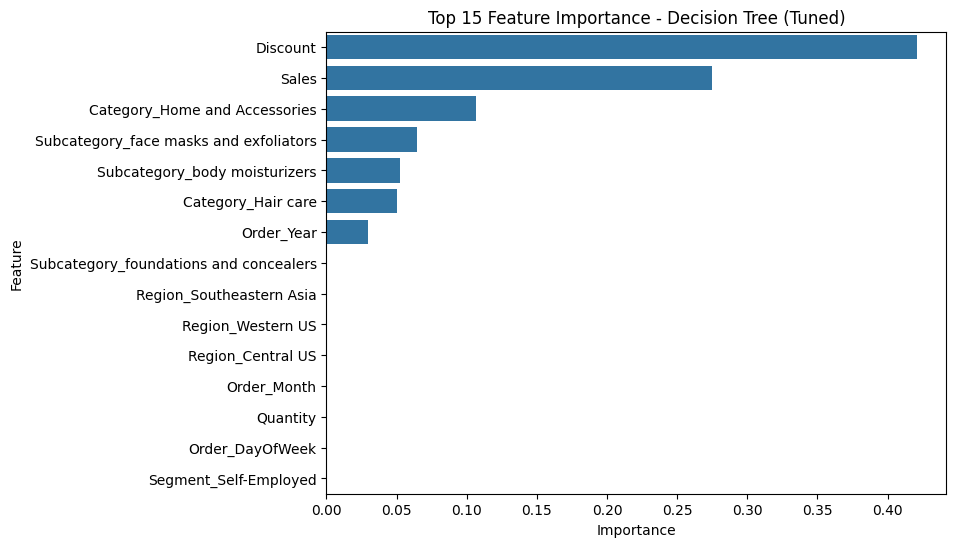

                                   Feature  Importance
2                                 Discount    0.420880
1                                    Sales    0.274877
52           Category_Home and Accessories    0.106314
42  Subcategory_face masks and exfoliators    0.064255
39           Subcategory_body moisturizers    0.052435
51                      Category_Hair care    0.050200
3                               Order_Year    0.029815
44  Subcategory_foundations and concealers    0.000292
21                Region_Southeastern Asia    0.000285
29                       Region_Western US    0.000159
12                       Region_Central US    0.000126
4                              Order_Month    0.000103
0                                 Quantity    0.000067
5                          Order_DayOfWeek    0.000065
7                    Segment_Self-Employed    0.000058


In [49]:
feat_imp_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': best_dt.feature_importances_
}).sort_values(by='Importance', ascending=False).head(15)

plt.figure(figsize=(8,6))
sns.barplot(data=feat_imp_df, x='Importance', y='Feature')
plt.title('Top 15 Feature Importance - Decision Tree (Tuned)')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

print(feat_imp_df)

Menganalisis fitur mana yang paling dominan memengaruhi hasil klasifikasi, yang menunjukkan bahwa Discount adalah faktor kunci penentu profit.

## 14. Kesimpulan

- Model dengan performa terbaik pada data test adalah **Decision Tree** (Test Accuracy 99.93%), diikuti **Random Forest** (99.47%), **Logistic Regression** (95.15%), dan **SVM** (91.30%).
- Gap antara Train Accuracy dan Test Accuracy untuk semua model kecil (di bawah 1.1%), artinya tidak ada indikasi overfitting yang serius — termasuk Decision Tree dan Random Forest yang biasanya rawan overfit.
- Setelah hyperparameter tuning, Random Forest terbaik diperoleh dengan `n_estimators=200, max_depth=None, min_samples_split=2, min_samples_leaf=1`, menghasilkan Test Accuracy 99.48% (hampir sama dengan sebelum tuning, menunjukkan parameter default Random Forest sudah cukup optimal untuk dataset ini).
- Berdasarkan feature importance, fitur yang paling berpengaruh terhadap kategori profit adalah **Discount** (35.8%), **Sales** (24.2%), dan **Quantity** (5.3%) — sejalan dengan insight EDA di awal bahwa Discount berkorelasi negatif kuat dengan Profit, sementara Sales berkorelasi positif.
- Insight bisnis: karena Discount adalah faktor paling dominan terhadap risiko rugi, kebijakan diskon perlu dikontrol lebih hati-hati per kategori produk (terutama kategori dengan diskon rata-rata tinggi pada EDA bagian 4.7), agar tidak menggerus profit secara signifikan.